In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install -q kaggle scikit-learn matplotlib pandas pillow opencv-python

cek gpu

In [ ]:
import os
import json
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
tf.__version__

'2.20.0'

In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/skripsi_penyakit_ayam"
DATA_DIR = f"{PROJECT_DIR}/dataset"
MODEL_DIR = f"{PROJECT_DIR}/models"
RESULT_DIR = f"{PROJECT_DIR}/results"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print("Folder siap:")
print(PROJECT_DIR)

Folder siap:
/content/drive/MyDrive/skripsi_penyakit_ayam


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/skripsi_penyakit_ayam"
DATA_DIR = f"{PROJECT_DIR}/dataset"
MODEL_DIR = f"{PROJECT_DIR}/models"
RESULT_DIR = f"{PROJECT_DIR}/results"

print("Project:", PROJECT_DIR)
print("Dataset folder:", DATA_DIR)
print("Models folder:", MODEL_DIR)
print("Results folder:", RESULT_DIR)

print("\nIsi folder dataset:")
print(os.listdir(DATA_DIR))

Project: /content/drive/MyDrive/skripsi_penyakit_ayam
Dataset folder: /content/drive/MyDrive/skripsi_penyakit_ayam/dataset
Models folder: /content/drive/MyDrive/skripsi_penyakit_ayam/models
Results folder: /content/drive/MyDrive/skripsi_penyakit_ayam/results

Isi folder dataset:
[]


penyimpanan dataset ayam

In [ ]:
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = ' ' * 2 * (level + 1)
    for f in files[:5]:
        print(f"{subindent}{f}")

raw/
  train_data.csv
  Train/
    cocci.1449.jpg
    salmo.158.jpg
    cocci.248.jpg
    healthy.342.jpg
    pcrhealthy.66.jpg


In [ ]:
print(os.listdir(DATA_DIR))

['raw']


In [ ]:
import os
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/skripsi_penyakit_ayam"
DATA_DIR = f"{PROJECT_DIR}/dataset"
MODEL_DIR = f"{PROJECT_DIR}/models"
RESULT_DIR = f"{PROJECT_DIR}/results"

RAW_DIR = f"{DATA_DIR}/raw"
CSV_PATH = f"{RAW_DIR}/train_data.csv"
IMAGE_DIR = f"{RAW_DIR}/Train"

df = pd.read_csv(CSV_PATH)

print("Jumlah data:", len(df))
print("\nNama kolom:")
print(df.columns.tolist())

print("\n5 data pertama:")
display(df.head())

print("\nJumlah label:")
print(df.iloc[:, -1].value_counts())

Jumlah data: 8067

Nama kolom:
['images', 'label']

5 data pertama:


,images,label
0,salmo.1558.jpg,Salmonella
1,cocci.1866.jpg,Coccidiosis
2,cocci.171.jpg,Coccidiosis
3,salmo.1484.jpg,Salmonella
4,ncd.100.jpg,New Castle Disease



Jumlah label:
label
Salmonella            2625
Coccidiosis           2476
Healthy               2404
New Castle Disease     562
Name: count, dtype: int64


In [ ]:
import os

df["image_path"] = df["images"].apply(lambda x: os.path.join(IMAGE_DIR, x))

df["file_exists"] = df["image_path"].apply(os.path.exists)

print("Total data:", len(df))
print("File ditemukan:", df["file_exists"].sum())
print("File tidak ditemukan:", (~df["file_exists"]).sum())

df_missing = df[df["file_exists"] == False]
display(df_missing.head())

Total data: 8067
File ditemukan: 8067
File tidak ditemukan: 0


,images,label,image_path,file_exists


In [ ]:
from PIL import Image
from tqdm import tqdm

valid_paths = []
invalid_paths = []

for path in tqdm(df["image_path"]):
    try:
        img = Image.open(path)
        img.verify()
        valid_paths.append(path)
    except Exception as e:
        invalid_paths.append(path)

print("Gambar valid:", len(valid_paths))
print("Gambar rusak:", len(invalid_paths))

if len(invalid_paths) > 0:
    print("Contoh gambar rusak:")
    print(invalid_paths[:10])

100%|██████████| 8067/8067 [00:00<00:00, 15334.73it/s]

Gambar valid: 8067
Gambar rusak: 0


In [ ]:
df_clean = df[df["file_exists"] == True].copy()

if len(invalid_paths) > 0:
    df_clean = df_clean[~df_clean["image_path"].isin(invalid_paths)].copy()

df_clean = df_clean[["images", "label", "image_path"]].copy()

print("Data bersih:", len(df_clean))
print(df_clean["label"].value_counts())

Data bersih: 8067
label
Salmonella            2625
Coccidiosis           2476
Healthy               2404
New Castle Disease     562
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    stratify=df_clean["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nDistribusi train:")
print(train_df["label"].value_counts())

print("\nDistribusi validation:")
print(val_df["label"].value_counts())

print("\nDistribusi test:")
print(test_df["label"].value_counts())

Train: 5646
Validation: 1210
Test: 1211

Distribusi train:
label
Salmonella            1837
Coccidiosis           1733
Healthy               1683
New Castle Disease     393
Name: count, dtype: int64

Distribusi validation:
label
Salmonella            394
Coccidiosis           371
Healthy               360
New Castle Disease     85
Name: count, dtype: int64

Distribusi test:
label
Salmonella            394
Coccidiosis           372
Healthy               361
New Castle Disease     84
Name: count, dtype: int64


In [ ]:
train_df.to_csv(f"{RESULT_DIR}/train_split.csv", index=False)
val_df.to_csv(f"{RESULT_DIR}/val_split.csv", index=False)
test_df.to_csv(f"{RESULT_DIR}/test_split.csv", index=False)

print("Split dataset berhasil disimpan ke folder results.")

Split dataset berhasil disimpan ke folder results.


In [ ]:
class_names = sorted(df_clean["label"].unique())

label_to_index = {label: idx for idx, label in enumerate(class_names)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

print("Label to index:")
print(label_to_index)

print("\nIndex to label:")
print(index_to_label)

Label to index:
{'Coccidiosis': 0, 'Healthy': 1, 'New Castle Disease': 2, 'Salmonella': 3}

Index to label:
{0: 'Coccidiosis', 1: 'Healthy', 2: 'New Castle Disease', 3: 'Salmonella'}


In [ ]:
import json

labels_path = f"{MODEL_DIR}/labels.json"

with open(labels_path, "w") as f:
    json.dump(index_to_label, f, indent=4)

print("labels.json disimpan di:", labels_path)

labels.json disimpan di: /content/drive/MyDrive/skripsi_penyakit_ayam/models/labels.json


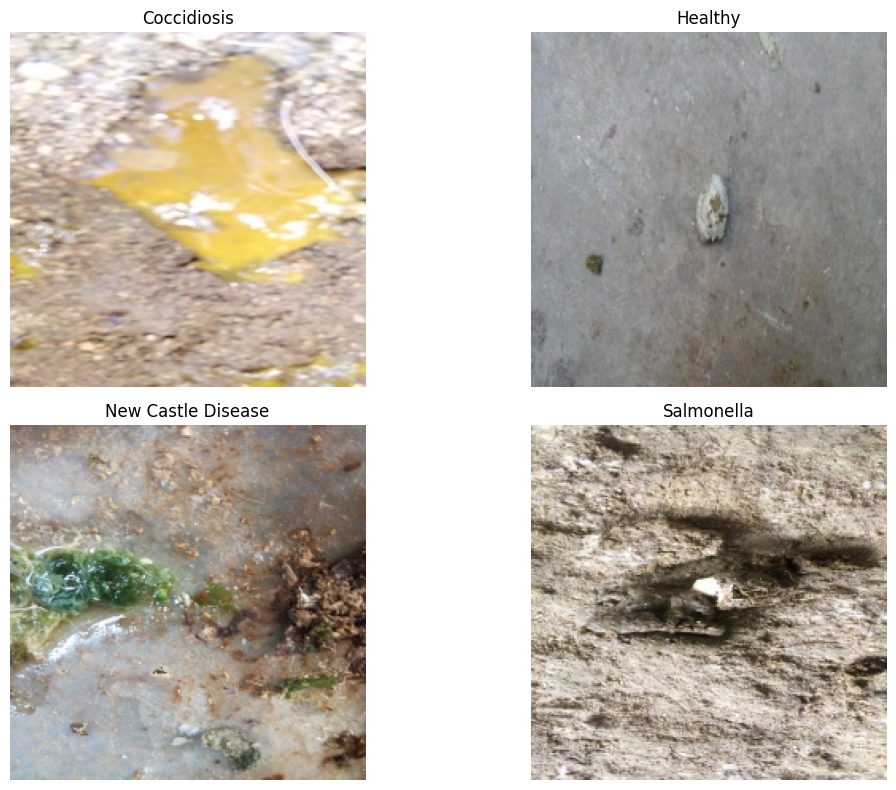

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(12, 8))

for i, label in enumerate(class_names):
    sample_path = df_clean[df_clean["label"] == label]["image_path"].sample(1, random_state=42).values[0]
    img = Image.open(sample_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

**Tahap Membuat PipeLine**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [ ]:
class_names = sorted(df_clean["label"].unique())

label_to_index = {label: idx for idx, label in enumerate(class_names)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

print("Class names:", class_names)
print("Label to index:", label_to_index)
print("Index to label:", index_to_label)

train_df["label_index"] = train_df["label"].map(label_to_index)
val_df["label_index"] = val_df["label"].map(label_to_index)
test_df["label_index"] = test_df["label"].map(label_to_index)

Class names: ['Coccidiosis', 'Healthy', 'New Castle Disease', 'Salmonella']
Label to index: {'Coccidiosis': 0, 'Healthy': 1, 'New Castle Disease': 2, 'Salmonella': 3}
Index to label: {0: 'Coccidiosis', 1: 'Healthy', 2: 'New Castle Disease', 3: 'Salmonella'}


In [ ]:
import json

labels_path = f"{MODEL_DIR}/labels.json"

with open(labels_path, "w") as f:
    json.dump(index_to_label, f, indent=4)

print("labels.json berhasil disimpan:", labels_path)

labels.json berhasil disimpan: /content/drive/MyDrive/skripsi_penyakit_ayam/models/labels.json


In [ ]:
def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

In [ ]:
def create_dataset(dataframe, shuffle=False):
    image_paths = dataframe["image_path"].values
    labels = dataframe["label_index"].values

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(load_image, num_parallel_calls=AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=SEED)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df, shuffle=False)
test_ds = create_dataset(test_df, shuffle=False)

print("Dataset TensorFlow siap.")

Dataset TensorFlow siap.


In [ ]:
for images, labels in train_ds.take(1):
    print("Shape gambar:", images.shape)
    print("Shape label:", labels.shape)
    print("Label contoh:", labels[:10].numpy())

Shape gambar: (32, 224, 224, 3)
Shape label: (32,)
Label contoh: [3 1 3 0 0 1 0 1 3 3]


Data augmentation

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

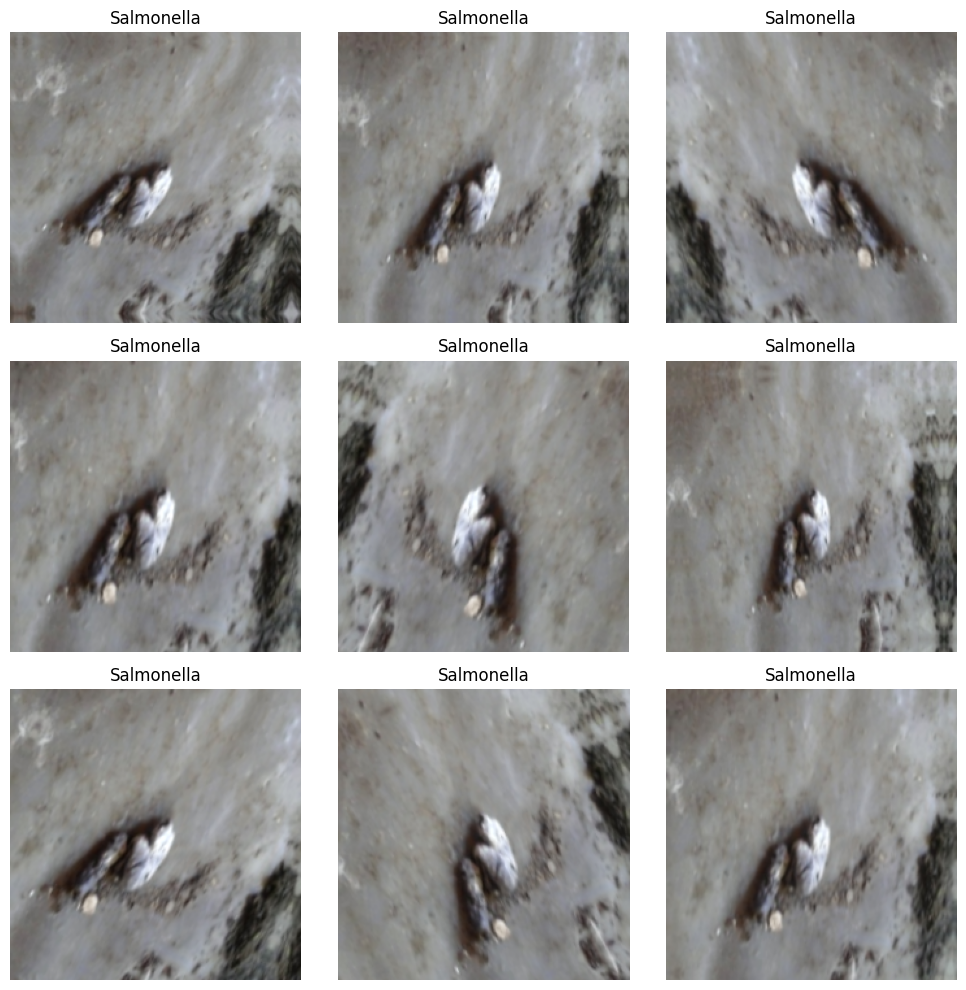

In [ ]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    sample_image = images[0]
    sample_label = labels[0].numpy()

    plt.figure(figsize=(10, 10))
    for i in range(9):
        augmented_image = data_augmentation(tf.expand_dims(sample_image, 0), training=True)

        plt.subplot(3, 3, i + 1)
        plt.imshow(tf.cast(augmented_image[0], tf.uint8))
        plt.title(index_to_label[int(sample_label)])
        plt.axis("off")

    plt.tight_layout()
    plt.show()
    break

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array(list(label_to_index.values())),
    y=train_df["label_index"].values
)

class_weights = {
    i: weight for i, weight in enumerate(class_weights_array)
}

print("Class weights:")
for idx, weight in class_weights.items():
    print(index_to_label[idx], ":", weight)

Class weights:
Coccidiosis : 0.8144835545297172
Healthy : 0.838680926916221
New Castle Disease : 3.5916030534351147
Salmonella : 0.7683723462166576


baseline cnn sederhana

In [ ]:
num_classes = len(class_names)

baseline_model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,276 (430.77 KB)

 Trainable params: 110,276 (430.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS_BASELINE = 10

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_BASELINE,
    class_weight=class_weights
)

Epoch 1/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.5375 - loss: 1.1498 - val_accuracy: 0.6636 - val_loss: 0.9154
Epoch 2/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.6847 - loss: 0.9012 - val_accuracy: 0.5727 - val_loss: 0.9476
Epoch 3/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/step - accuracy: 0.7024 - loss: 0.8468 - val_accuracy: 0.6537 - val_loss: 0.8566
Epoch 4/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.7092 - loss: 0.8010 - val_accuracy: 0.6917 - val_loss: 0.7964
Epoch 5/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - accuracy: 0.7391 - loss: 0.7359 - val_accuracy: 0.7438 - val_loss: 0.7142
Epoch 6/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.7605 - loss: 0.6978 - val_accuracy: 0.8091 - val_loss: 0.6105
Epoch 7/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - accuracy: 0.7862 - loss: 0.6443 - val_accuracy: 0.8157 - val_loss: 0.6033
Epoch 8/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.7880 - loss: 0.6365 - 

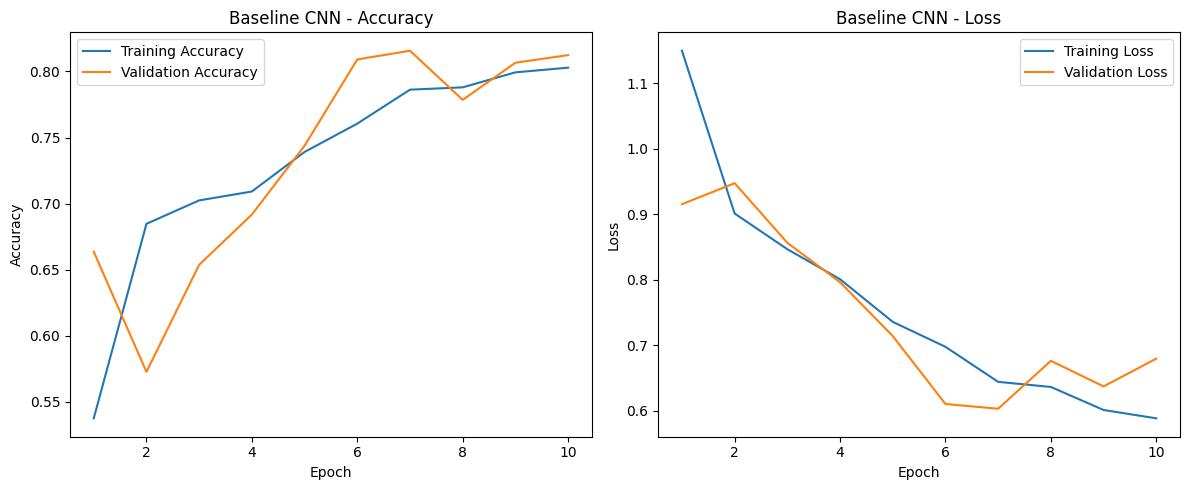

In [ ]:
def plot_training_history(history, title):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(baseline_history, "Baseline CNN")

In [ ]:
test_loss, test_accuracy = baseline_model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.7886 - loss: 0.6765
Test Loss: 0.6764655709266663
Test Accuracy: 0.7886044383049011


In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = baseline_model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                    precision    recall  f1-score   support

       Coccidiosis       0.96      0.82      0.88       372
           Healthy       0.63      0.95      0.75       361
New Castle Disease       0.74      0.51      0.61        84
        Salmonella       0.92      0.67      0.77       394

          accuracy                           0.79      1211
         macro avg       0.81      0.74      0.75      1211
      weighted avg       0.83      0.79      0.79      1211



<Figure size 800x800 with 0 Axes>

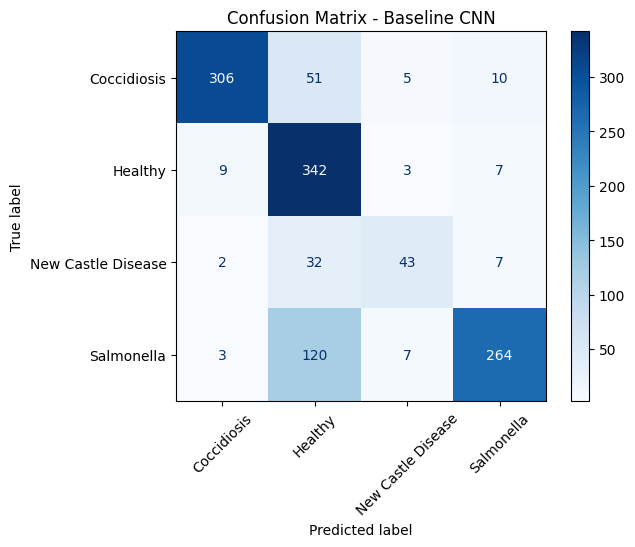

In [ ]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(8, 8))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Baseline CNN")
plt.show()

In [ ]:
baseline_model_path = f"{MODEL_DIR}/baseline_cnn_penyakit_ayam.keras"
baseline_model.save(baseline_model_path)

print("Baseline model disimpan di:", baseline_model_path)

Baseline model disimpan di: /content/drive/MyDrive/skripsi_penyakit_ayam/models/baseline_cnn_penyakit_ayam.keras


**MobileNetV2**

In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/skripsi_penyakit_ayam"
DATA_DIR = f"{PROJECT_DIR}/dataset"
MODEL_DIR = f"{PROJECT_DIR}/models"
RESULT_DIR = f"{PROJECT_DIR}/results"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print("Struktur folder berhasil dibuat:")
print(PROJECT_DIR)
print(DATA_DIR)
print(MODEL_DIR)
print(RESULT_DIR)

Struktur folder berhasil dibuat:
/content/drive/MyDrive/skripsi_penyakit_ayam
/content/drive/MyDrive/skripsi_penyakit_ayam/dataset
/content/drive/MyDrive/skripsi_penyakit_ayam/models
/content/drive/MyDrive/skripsi_penyakit_ayam/results


In [16]:
ZIP_PATH = f"{DATA_DIR}/datasetCD.zip"

print("ZIP ada:", os.path.exists(ZIP_PATH))
print("Lokasi ZIP:", ZIP_PATH)

print("\nIsi folder dataset:")
print(os.listdir(DATA_DIR))

ZIP ada: True
Lokasi ZIP: /content/drive/MyDrive/skripsi_penyakit_ayam/dataset/datasetCD.zip

Isi folder dataset:
['raw', '.ipynb_checkpoints', 'datasetCD.zip']


In [17]:
import zipfile

RAW_DIR = f"{DATA_DIR}/raw"

os.makedirs(RAW_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(RAW_DIR)

print("Dataset berhasil diextract ke:", RAW_DIR)

Dataset berhasil diextract ke: /content/drive/MyDrive/skripsi_penyakit_ayam/dataset/raw


In [18]:
for root, dirs, files in os.walk(RAW_DIR):
    level = root.replace(RAW_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = ' ' * 2 * (level + 1)
    for f in files[:5]:
        print(f"{subindent}{f}")

raw/
  train_data.csv
  Train/
    cocci.0.jpg
    cocci.1.jpg
    cocci.10.jpg
    cocci.100.jpg
    cocci.1000.jpg


In [20]:
CSV_PATH = f"{RAW_DIR}/train_data.csv"
IMAGE_DIR = f"{RAW_DIR}/Train"

print("CSV ada:", os.path.exists(CSV_PATH))
print("Folder gambar ada:", os.path.exists(IMAGE_DIR))

CSV ada: True
Folder gambar ada: True


In [21]:
import os
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/skripsi_penyakit_ayam"
DATA_DIR = f"{PROJECT_DIR}/dataset"
MODEL_DIR = f"{PROJECT_DIR}/models"
RESULT_DIR = f"{PROJECT_DIR}/results"

RAW_DIR = f"{DATA_DIR}/raw"
CSV_PATH = f"{RAW_DIR}/train_data.csv"
IMAGE_DIR = f"{RAW_DIR}/Train"

print("CSV ada:", os.path.exists(CSV_PATH))
print("Folder gambar ada:", os.path.exists(IMAGE_DIR))

CSV ada: True
Folder gambar ada: True


In [22]:
df = pd.read_csv(CSV_PATH)

print("Jumlah data:", len(df))
print("Kolom:", df.columns.tolist())
display(df.head())
print(df["label"].value_counts())

Jumlah data: 8067
Kolom: ['images', 'label']


,images,label
0,salmo.1558.jpg,Salmonella
1,cocci.1866.jpg,Coccidiosis
2,cocci.171.jpg,Coccidiosis
3,salmo.1484.jpg,Salmonella
4,ncd.100.jpg,New Castle Disease


label
Salmonella            2625
Coccidiosis           2476
Healthy               2404
New Castle Disease     562
Name: count, dtype: int64


In [23]:
df["image_path"] = df["images"].apply(lambda x: os.path.join(IMAGE_DIR, x))
df["file_exists"] = df["image_path"].apply(os.path.exists)

print("Total data:", len(df))
print("File ditemukan:", df["file_exists"].sum())
print("File tidak ditemukan:", (~df["file_exists"]).sum())

display(df[df["file_exists"] == False].head())

Total data: 8067
File ditemukan: 8067
File tidak ditemukan: 0


,images,label,image_path,file_exists


In [24]:
import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [25]:
PROJECT_DIR = "/content/drive/MyDrive/skripsi_penyakit_ayam"
DATA_DIR = f"{PROJECT_DIR}/dataset"
MODEL_DIR = f"{PROJECT_DIR}/models"
RESULT_DIR = f"{PROJECT_DIR}/results"

RAW_DIR = f"{DATA_DIR}/raw"
CSV_PATH = f"{RAW_DIR}/train_data.csv"
IMAGE_DIR = f"{RAW_DIR}/Train"

print("CSV ada:", os.path.exists(CSV_PATH))
print("Folder gambar ada:", os.path.exists(IMAGE_DIR))

CSV ada: True
Folder gambar ada: True


In [26]:
df = pd.read_csv(CSV_PATH)

df["image_path"] = df["images"].apply(lambda x: os.path.join(IMAGE_DIR, x))
df["file_exists"] = df["image_path"].apply(os.path.exists)

print("Jumlah data:", len(df))
print("File ditemukan:", df["file_exists"].sum())
print("File tidak ditemukan:", (~df["file_exists"]).sum())

print("\nDistribusi label:")
print(df["label"].value_counts())

display(df.head())

Jumlah data: 8067
File ditemukan: 8067
File tidak ditemukan: 0

Distribusi label:
label
Salmonella            2625
Coccidiosis           2476
Healthy               2404
New Castle Disease     562
Name: count, dtype: int64


,images,label,image_path,file_exists
0,salmo.1558.jpg,Salmonella,/content/drive/MyDrive/skripsi_penyakit_ayam/d...,True
1,cocci.1866.jpg,Coccidiosis,/content/drive/MyDrive/skripsi_penyakit_ayam/d...,True
2,cocci.171.jpg,Coccidiosis,/content/drive/MyDrive/skripsi_penyakit_ayam/d...,True
3,salmo.1484.jpg,Salmonella,/content/drive/MyDrive/skripsi_penyakit_ayam/d...,True
4,ncd.100.jpg,New Castle Disease,/content/drive/MyDrive/skripsi_penyakit_ayam/d...,True


In [27]:
df_clean = df[df["file_exists"] == True][["images", "label", "image_path"]].copy()

print("Data bersih:", len(df_clean))

Data bersih: 8067


In [28]:
train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    stratify=df_clean["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nDistribusi train:")
print(train_df["label"].value_counts())

print("\nDistribusi validation:")
print(val_df["label"].value_counts())

print("\nDistribusi test:")
print(test_df["label"].value_counts())

Train: 5646
Validation: 1210
Test: 1211

Distribusi train:
label
Salmonella            1837
Coccidiosis           1733
Healthy               1683
New Castle Disease     393
Name: count, dtype: int64

Distribusi validation:
label
Salmonella            394
Coccidiosis           371
Healthy               360
New Castle Disease     85
Name: count, dtype: int64

Distribusi test:
label
Salmonella            394
Coccidiosis           372
Healthy               361
New Castle Disease     84
Name: count, dtype: int64


In [29]:
class_names = sorted(df_clean["label"].unique())

label_to_index = {label: idx for idx, label in enumerate(class_names)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

train_df["label_index"] = train_df["label"].map(label_to_index)
val_df["label_index"] = val_df["label"].map(label_to_index)
test_df["label_index"] = test_df["label"].map(label_to_index)

num_classes = len(class_names)

print("Class names:", class_names)
print("Label to index:", label_to_index)
print("Jumlah kelas:", num_classes)

Class names: ['Coccidiosis', 'Healthy', 'New Castle Disease', 'Salmonella']
Label to index: {'Coccidiosis': 0, 'Healthy': 1, 'New Castle Disease': 2, 'Salmonella': 3}
Jumlah kelas: 4


In [30]:
labels_path = f"{MODEL_DIR}/labels.json"

with open(labels_path, "w") as f:
    json.dump(index_to_label, f, indent=4)

print("labels.json disimpan di:", labels_path)

labels.json disimpan di: /content/drive/MyDrive/skripsi_penyakit_ayam/models/labels.json


In [31]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def create_dataset(dataframe, shuffle=False):
    image_paths = dataframe["image_path"].values
    labels = dataframe["label_index"].values

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(load_image, num_parallel_calls=AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=SEED)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df, shuffle=False)
test_ds = create_dataset(test_df, shuffle=False)

print("Dataset TensorFlow siap.")

Dataset TensorFlow siap.


In [32]:
for images, labels in train_ds.take(1):
    print("Shape gambar:", images.shape)
    print("Shape label:", labels.shape)
    print("Contoh label:", labels[:10].numpy())

Shape gambar: (32, 224, 224, 3)
Shape label: (32,)
Contoh label: [3 1 3 0 0 1 0 1 3 3]


In [33]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

In [34]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array(list(label_to_index.values())),
    y=train_df["label_index"].values
)

class_weights = {
    i: weight for i, weight in enumerate(class_weights_array)
}

print("Class weights:")
for idx, weight in class_weights.items():
    print(index_to_label[idx], ":", weight)

Class weights:
Coccidiosis : 0.8144835545297172
Healthy : 0.838680926916221
New Castle Disease : 3.5916030534351147
Salmonella : 0.7683723462166576


In [37]:
base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

mobilenet_model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Lambda(
        keras.applications.mobilenet_v2.preprocess_input,
        name="mobilenetv2_preprocess"
    ),

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_preprocess (Lambda) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [38]:
EPOCHS_MOBILENET = 10

mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_MOBILENET,
    class_weight=class_weights
)

Epoch 1/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 48s 104ms/step - accuracy: 0.7467 - loss: 0.6885 - val_accuracy: 0.8967 - val_loss: 0.3186
Epoch 2/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 33s 86ms/step - accuracy: 0.8567 - loss: 0.4109 - val_accuracy: 0.8860 - val_loss: 0.3270
Epoch 3/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 33s 86ms/step - accuracy: 0.8711 - loss: 0.3662 - val_accuracy: 0.9116 - val_loss: 0.2537
Epoch 4/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 31s 83ms/step - accuracy: 0.8976 - loss: 0.3112 - val_accuracy: 0.9240 - val_loss: 0.2354
Epoch 5/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - accuracy: 0.8944 - loss: 0.2984 - val_accuracy: 0.9273 - val_loss: 0.2235
Epoch 6/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.9003 - loss: 0.2825 - val_accuracy: 0.9256 - val_loss: 0.2245
Epoch 7/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step - accuracy: 0.9017 - loss: 0.2834 - val_accuracy: 0.9223 - val_loss: 0.2382
Epoch 8/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 31s 83ms/step - accuracy: 0.9060 - loss: 0.2655 -

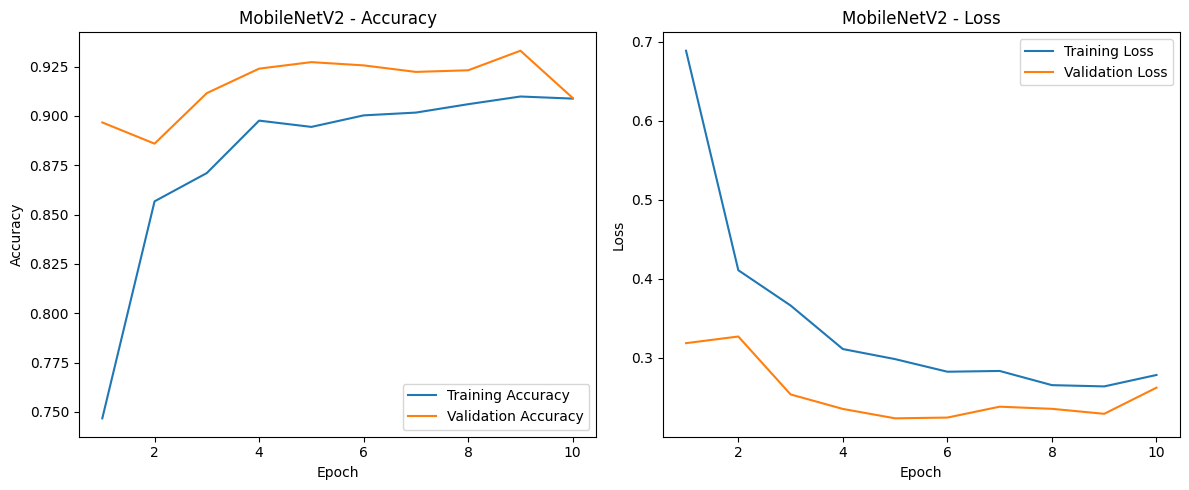

In [39]:
def plot_training_history(history, title):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(mobilenet_history, "MobileNetV2")

In [40]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 268ms/step - accuracy: 0.9125 - loss: 0.2800
Test Loss: 0.28000330924987793
Test Accuracy: 0.9124690294265747


In [41]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step - accuracy: 0.9125 - loss: 0.2800
Test Loss: 0.28000330924987793
Test Accuracy: 0.9124690294265747


In [42]:
y_true_mobilenet = []
y_pred_mobilenet = []

for images, labels in test_ds:
    preds = mobilenet_model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    y_true_mobilenet.extend(labels.numpy())
    y_pred_mobilenet.extend(pred_labels)

print(classification_report(
    y_true_mobilenet,
    y_pred_mobilenet,
    target_names=class_names
))

                    precision    recall  f1-score   support

       Coccidiosis       0.98      0.94      0.96       372
           Healthy       0.84      0.97      0.90       361
New Castle Disease       0.74      0.82      0.78        84
        Salmonella       0.99      0.85      0.91       394

          accuracy                           0.91      1211
         macro avg       0.89      0.90      0.89      1211
      weighted avg       0.92      0.91      0.91      1211



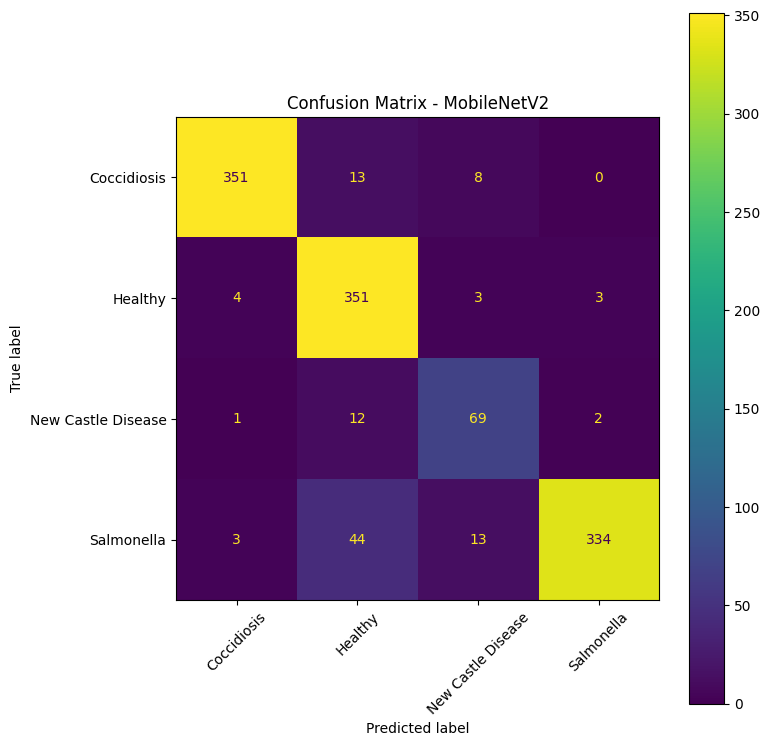

In [43]:
cm_mobilenet = confusion_matrix(y_true_mobilenet, y_pred_mobilenet)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mobilenet,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - MobileNetV2")
plt.tight_layout()
plt.show()

In [44]:
mobilenet_model_path = f"{MODEL_DIR}/mobilenetv2_penyakit_ayam.keras"
mobilenet_model.save(mobilenet_model_path)

print("MobileNetV2 model disimpan di:", mobilenet_model_path)

MobileNetV2 model disimpan di: /content/drive/MyDrive/skripsi_penyakit_ayam/models/mobilenetv2_penyakit_ayam.keras


finetuning mobilevnet


In [45]:
mobilenet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_preprocess (Lambda) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,273,358 (8.67 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 10,250 (40.04 KB)

In [46]:
for i, layer in enumerate(mobilenet_model.layers):
    print(i, layer.name, type(layer))

0 data_augmentation <class 'keras.src.models.sequential.Sequential'>
1 mobilenetv2_preprocess <class 'keras.src.layers.core.lambda_layer.Lambda'>
2 mobilenetv2_1.00_224 <class 'keras.src.models.functional.Functional'>
3 global_average_pooling2d_2 <class 'keras.src.layers.pooling.global_average_pooling2d.GlobalAveragePooling2D'>
4 dropout_2 <class 'keras.src.layers.regularization.dropout.Dropout'>
5 dense_2 <class 'keras.src.layers.core.dense.Dense'>


In [47]:
base_model = mobilenet_model.layers[2]

print(base_model.name)
print("Jumlah layer dalam base model:", len(base_model.layers))

mobilenetv2_1.00_224
Jumlah layer dalam base model: 154


In [48]:
base_model.trainable = True

fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

In [49]:
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

In [50]:
trainable_count = sum([1 for layer in base_model.layers if layer.trainable])
non_trainable_count = sum([1 for layer in base_model.layers if not layer.trainable])

print("Trainable layers:", trainable_count)
print("Non-trainable layers:", non_trainable_count)

Trainable layers: 36
Non-trainable layers: 118


In [51]:
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [52]:
checkpoint_path = f"{MODEL_DIR}/mobilenetv2_finetuned_best.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [53]:
EPOCHS_FINE_TUNE = 10

fine_tune_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE_TUNE,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9078 - loss: 0.2600
Epoch 1: val_accuracy improved from None to 0.93058, saving model to /content/drive/MyDrive/skripsi_penyakit_ayam/models/mobilenetv2_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/skripsi_penyakit_ayam/models/mobilenetv2_finetuned_best.keras
177/177 ━━━━━━━━━━━━━━━━━━━━ 47s 112ms/step - accuracy: 0.9107 - loss: 0.2535 - val_accuracy: 0.9306 - val_loss: 0.2169 - learning_rate: 1.0000e-05
Epoch 2/10
176/177 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9199 - loss: 0.2312
Epoch 2: val_accuracy improved from 0.93058 to 0.94132, saving model to /content/drive/MyDrive/skripsi_penyakit_ayam/models/mobilenetv2_finetuned_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/skripsi_penyakit_ayam/models/mobilenetv2_finetuned_best.keras
177/177 ━━━━━━━━━━━━━━━━━━━━ 39s 116ms/step - accuracy: 0.9191 - loss: 0.2366 - val_accuracy: 0.9413 - val_loss: 0.1882 - learn

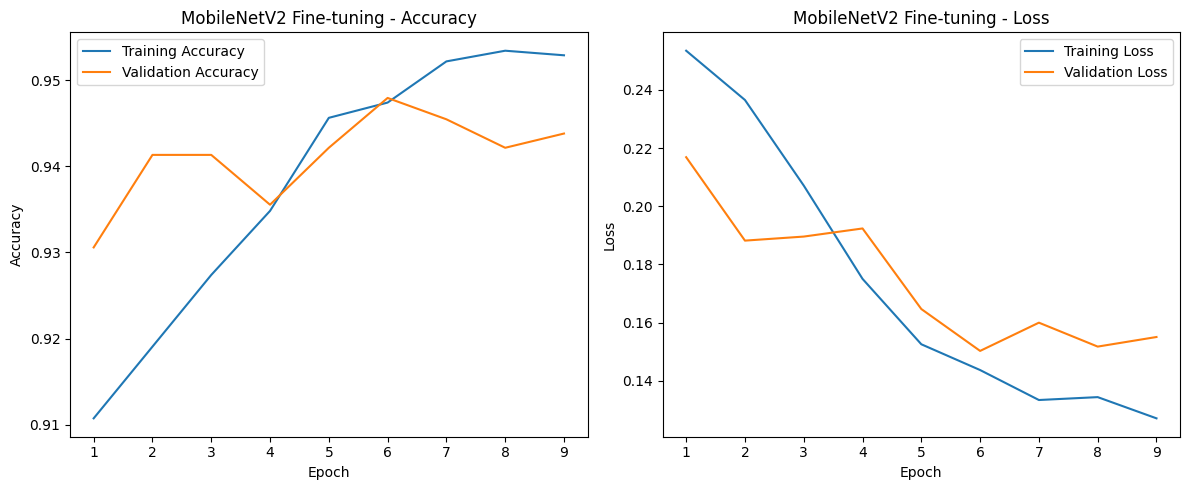

In [54]:
plot_training_history(fine_tune_history, "MobileNetV2 Fine-tuning")

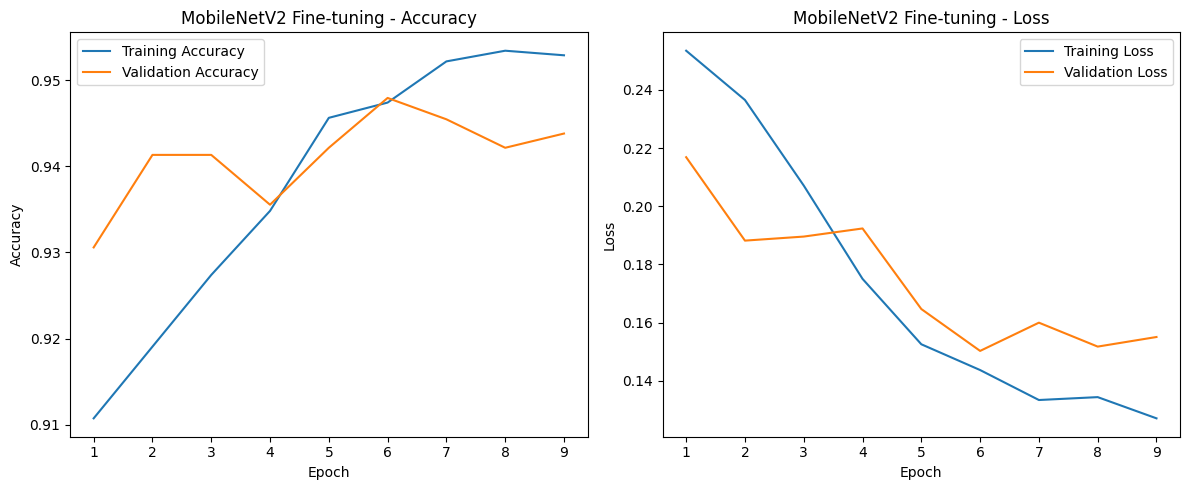

In [55]:
def plot_training_history(history, title):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(fine_tune_history, "MobileNetV2 Fine-tuning")


In [56]:
test_loss_ft, test_accuracy_ft = mobilenet_model.evaluate(test_ds)

print("Fine-tuned Test Loss:", test_loss_ft)
print("Fine-tuned Test Accuracy:", test_accuracy_ft)

38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 207ms/step - accuracy: 0.9513 - loss: 0.1755
Fine-tuned Test Loss: 0.17547914385795593
Fine-tuned Test Accuracy: 0.9512799382209778


In [57]:
y_true_ft = []
y_pred_ft = []

for images, labels in test_ds:
    preds = mobilenet_model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    y_true_ft.extend(labels.numpy())
    y_pred_ft.extend(pred_labels)

print(classification_report(
    y_true_ft,
    y_pred_ft,
    target_names=class_names
))

                    precision    recall  f1-score   support

       Coccidiosis       0.97      0.97      0.97       372
           Healthy       0.91      0.96      0.94       361
New Castle Disease       0.92      0.87      0.90        84
        Salmonella       0.98      0.94      0.96       394

          accuracy                           0.95      1211
         macro avg       0.95      0.94      0.94      1211
      weighted avg       0.95      0.95      0.95      1211



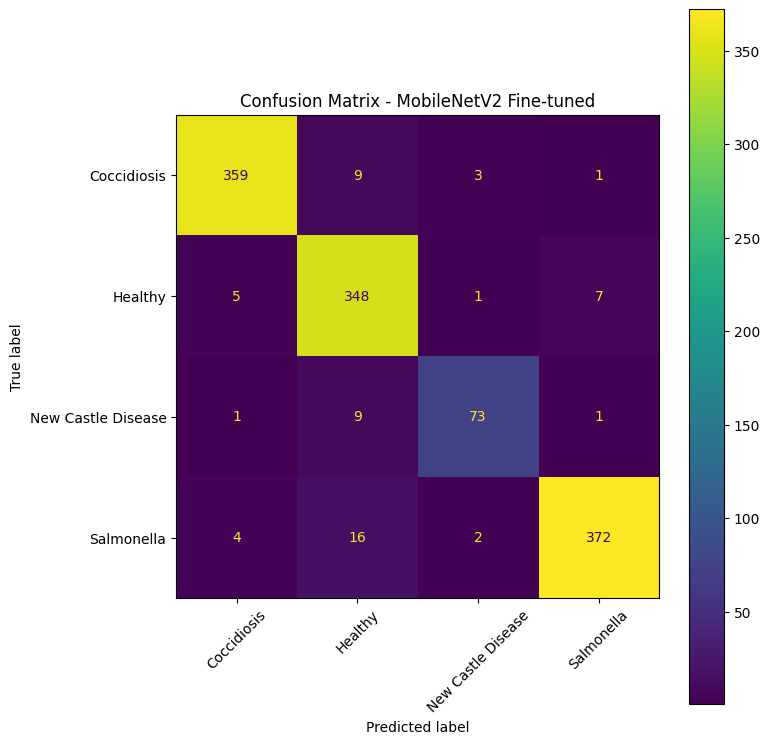

In [58]:
cm_ft = confusion_matrix(y_true_ft, y_pred_ft)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ft,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - MobileNetV2 Fine-tuned")
plt.tight_layout()
plt.show()

In [59]:
finetuned_model_path = f"{MODEL_DIR}/mobilenetv2_finetuned_penyakit_ayam.keras"
mobilenet_model.save(finetuned_model_path)

print("Fine-tuned model disimpan di:", finetuned_model_path)

Fine-tuned model disimpan di: /content/drive/MyDrive/skripsi_penyakit_ayam/models/mobilenetv2_finetuned_penyakit_ayam.keras


In [60]:
report_dict_ft = classification_report(
    y_true_ft,
    y_pred_ft,
    target_names=class_names,
    output_dict=True
)

report_df_ft = pd.DataFrame(report_dict_ft).transpose()
report_path_ft = f"{RESULT_DIR}/classification_report_mobilenetv2_finetuned.csv"
report_df_ft.to_csv(report_path_ft)

print("Report fine-tuned disimpan di:", report_path_ft)
display(report_df_ft)

Report fine-tuned disimpan di: /content/drive/MyDrive/skripsi_penyakit_ayam/results/classification_report_mobilenetv2_finetuned.csv


,precision,recall,f1-score,support
Coccidiosis,0.972900,0.965054,0.968961,372.00000
Healthy,0.910995,0.963989,0.936743,361.00000
New Castle Disease,0.924051,0.869048,0.895706,84.00000
Salmonella,0.976378,0.944162,0.960000,394.00000
accuracy,0.951280,0.951280,0.951280,0.95128
macro avg,0.946081,0.935563,0.940352,1211.00000
weighted avg,0.952189,0.951280,0.951360,1211.00000


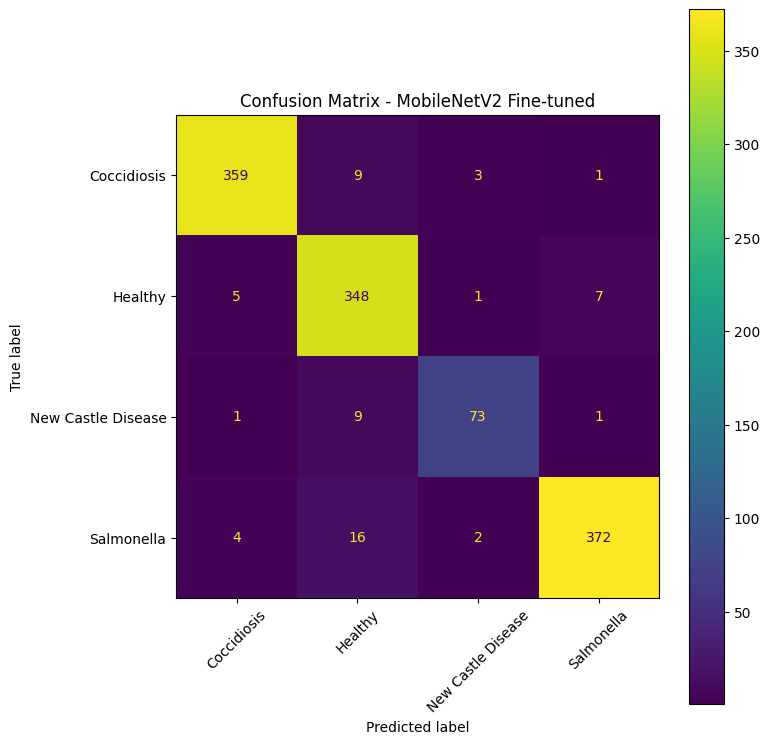

Confusion matrix fine-tuned disimpan di: /content/drive/MyDrive/skripsi_penyakit_ayam/results/confusion_matrix_mobilenetv2_finetuned.png


In [61]:
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ft,
    display_labels=class_names
)
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - MobileNetV2 Fine-tuned")
plt.tight_layout()

cm_path_ft = f"{RESULT_DIR}/confusion_matrix_mobilenetv2_finetuned.png"
plt.savefig(cm_path_ft, dpi=300)
plt.show()

print("Confusion matrix fine-tuned disimpan di:", cm_path_ft)